Imports

In [ ]:
import sys
import subprocess

print("Python utilisé :", sys.executable)

result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "setuptools"],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)


In [ ]:
import sys
import subprocess
import mlflow


print("✅ Installation terminée avec succès !")

## Regression logistique

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
import gc
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, make_scorer, ConfusionMatrixDisplay

# --- CONFIGURATION MLFLOW ---
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Projet_6")

# --- PARAMÈTRES MÉTIERS ---
cost_fn = 10  # Coût d'un Faux Négatif
cost_fp = 1   # Coût d'un Faux Positif

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (cost_fn * fn) + (cost_fp * fp)

# Le scorer métier : on veut minimiser le coût (greater_is_better=False)
cost_scorer = make_scorer(business_cost, greater_is_better=False)

# --- CHARGEMENT DES DONNÉES ---
df = pd.read_parquet('Datas/df_preprocessed.parquet')
train_df = df[df['TARGET'].notna()]
X = train_df.drop(columns=['TARGET']).replace([np.inf, -np.inf], np.nan)
y = train_df['TARGET']
del df  , train_df
gc.collect()

# --- PIPELINE ---
pipeline = Pipeline([
    ('preprocessor', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])),
    ('classifier', LogisticRegression(
        class_weight={0: cost_fp, 1: cost_fn},
        random_state=42,
        solver='liblinear'
    ))
])

# --- LANCEMENT DE L'EXPÉRIENCE ---
run_name = f"LR_costFN_{cost_fn}_CV"

with mlflow.start_run(run_name=run_name):
    
    # 1. Log des paramètres
    mlflow.log_params({
        "cost_fn": cost_fn,
        "cost_fp": cost_fp,
        "model_type": "LogisticRegression",
        "solver": "liblinear"
    })
    mlflow.set_tag("strategy", f"fn_cost_{cost_fn}")

    # 2. Définition des scores incluant le coût métier
    scoring = {
        'f1': 'f1', 
        'recall': 'recall', 
        'roc_auc': 'roc_auc', 
        'accuracy' : 'accuracy',
        'business_cost': cost_scorer
    }
    
    # 3. Validation croisée
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    
    # 4. Affichage et log des résultats
    for metric in scoring:
        mean_score = cv_results[f'test_{metric}'].mean()
        # On inverse le signe pour le coût métier afin d'afficher une valeur positive
        final_val = -mean_score if metric == 'business_cost' else mean_score
        mlflow.log_metric(f"mean_{metric}", final_val)
        print(f"Moyenne {metric} : {final_val:.4f}")

    # 5. Visualisation : Matrice de confusion
    pipeline.fit(X, y)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(pipeline, X, y, ax=ax, cmap="Blues")
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    
    print("Run terminé et logué dans MLflow.")

## Forêt Aléatoire

In [ ]:
import optuna
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, confusion_matrix


# ============================================================
# 1. Configuration
# ============================================================

DATA_PATH = "./Datas/df_preprocessed.parquet"
TARGET_COL = "TARGET"

EXPERIMENT_NAME = "Projet_6"
RUN_NAME = "RF_Full_Metrics_FN_10_With_Accuracy"

RANDOM_STATE = 42
N_SPLITS = 5

COST_FP = 1
COST_FN = 10


# ============================================================
# 2. Fonction de coût métier
# ============================================================

def business_cost_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = COST_FP * fp + COST_FN * fn
    return total_cost


cost_scorer = make_scorer(
    business_cost_score,
    greater_is_better=False
)


# ============================================================
# 3. Chargement des données
# ============================================================

df = pd.read_parquet(DATA_PATH)

print("Shape du dataset :", df.shape)
print("Colonnes :", df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"La colonne cible '{TARGET_COL}' est absente du fichier.")

df = df.dropna(subset=[TARGET_COL])
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

if "SK_ID_CURR" in X.columns:
    X = X.drop(columns=["SK_ID_CURR"])

# Remplacer les infinis par NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Remplacer les NaN par la médiane de chaque colonne
X = X.fillna(X.median())


print("Shape X :", X.shape)
print("Shape y :", y.shape)

print("Distribution de la cible :")
print(y.value_counts())
print(y.value_counts(normalize=True))


# ============================================================
# 4. Modèle Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# ============================================================
# 5. Métriques : fichier joint + accuracy
# ============================================================

scoring = {
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "business_cost": cost_scorer,
    "accuracy": "accuracy"
}


# ============================================================
# 6. Validation croisée
# ============================================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 7. Logging MLflow
# ============================================================
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # Paramètres logués
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("data_path", DATA_PATH)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_n_splits", N_SPLITS)
    mlflow.log_param("cost_fp", COST_FP)
    mlflow.log_param("cost_fn", COST_FN)
    mlflow.log_param("cost_ratio_fn_vs_fp", COST_FN / COST_FP)

    # Validation croisée
    cv_results = cross_validate(
        estimator=rf_model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    # Moyennes
    mean_f1 = cv_results["test_f1"].mean()
    mean_recall = cv_results["test_recall"].mean()
    mean_roc_auc = cv_results["test_roc_auc"].mean()
    mean_accuracy = cv_results["test_accuracy"].mean()

    # business_cost est négatif avec greater_is_better=False
    mean_business_cost = -cv_results["test_business_cost"].mean()

    # Log des métriques MLflow
    mlflow.log_metric("mean_f1", mean_f1)
    mlflow.log_metric("mean_recall", mean_recall)
    mlflow.log_metric("mean_roc_auc", mean_roc_auc)
    mlflow.log_metric("mean_accuracy", mean_accuracy)
    mlflow.log_metric("mean_business_cost", mean_business_cost)

    # Entraînement final sur toutes les données
    rf_model.fit(X, y)

    # Log du modèle
    mlflow.sklearn.log_model(
        sk_model=rf_model,
        artifact_path="model"
    )

    # Affichage console
    print("\nRésultats validation croisée :")
    print(f"mean_f1             : {mean_f1:.4f}")
    print(f"mean_recall         : {mean_recall:.4f}")
    print(f"mean_roc_auc        : {mean_roc_auc:.4f}")
    print(f"mean_accuracy       : {mean_accuracy:.4f}")
    print(f"mean_business_cost  : {mean_business_cost:.2f}")


Forêt aléatoire avec Optuna

In [ ]:
import optuna
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, confusion_matrix

# ============================================================
# 1. Configuration & Initialisation
# ============================================================
DATA_PATH = "./Datas/df_preprocessed.parquet"
TARGET_COL = "TARGET"
EXPERIMENT_NAME = "Projet_6"
RUN_NAME = "RF_Optuna_Business_Cost_FN_10"
RANDOM_STATE = 42
N_SPLITS = 5
N_TRIALS = 5

# Configuration MLflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)

# ============================================================
# 2. Fonctions métier
# ============================================================
def business_cost_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (1 * fp) + (10 * fn)

cost_scorer = make_scorer(business_cost_score, greater_is_better=False)

# Chargement et préparation des données
df = pd.read_parquet(DATA_PATH).dropna(subset=[TARGET_COL])
X = df.drop(columns=[TARGET_COL, "SK_ID_CURR"], errors='ignore')
y = df[TARGET_COL].astype(int)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

# ============================================================
# 3. Fonction objectif Optuna
# ============================================================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    
    cv_results = cross_validate(
        model, X, y, cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
        scoring={"business_cost": cost_scorer, 
            "f1": "f1", 
            "recall": "recall", 
            "roc_auc": "roc_auc"}, n_jobs=1
    )

    mean_cost = -cv_results["test_business_cost"].mean()
    mean_f1 = cv_results["test_f1"].mean()
    mean_recall = cv_results["test_recall"].mean()
    mean_roc_auc = cv_results["test_roc_auc"].mean()

    # Logging dans MLflow
    with mlflow.start_run(run_name=f"{RUN_NAME}_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.set_tag("RUN_Name", RUN_NAME)
        mlflow.log_metric("mean_business_cost", mean_cost)
        mlflow.log_metric("mean_f1", mean_f1)
        mlflow.log_metric("mean_recall", mean_recall)
        mlflow.log_metric("mean_roc_auc", mean_roc_auc)

    return mean_cost

# ============================================================
# 4. Exécution
# ============================================================
if __name__ == "__main__":
    with mlflow.start_run(run_name=RUN_NAME):
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS)
        
        mlflow.log_params(study.best_params)
        mlflow.set_tag("RUN_Name", RUN_NAME)
        mlflow.log_metric("best_business_cost", study.best_value)
        print(f"Optimisation terminée. Meilleur coût : {study.best_value}")

## LightGBM


In [ ]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
import mlflow.sklearn
import sklearn.metrics
import gc
import re
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score

# Chargement
df = pd.read_parquet('./Datas/df_preprocessed.parquet')
train_df = df[df['TARGET'].notnull()].copy()
test_df = df[df['TARGET'].isnull()].copy()
del df; gc.collect()

train_df = train_df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df = test_df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
feats = [f for f in train_df.columns if f not in ['TARGET','SK_ID_CURR','SK_ID_BUREAU','SK_ID_PREV','index']]

def display_importances(feature_importance_df_):
    cols = feature_importance_df_[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:40].index
    best_features = feature_importance_df_.loc[feature_importance_df_.feature.isin(cols)]
    plt.figure(figsize=(8, 10))
    sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
    plt.title('LightGBM Features (avg over folds)')
    plt.tight_layout()
    plt.savefig('lgbm_importances01.png')
    plt.show()

def kfold_lightgbm_mlflow(train_df, test_df, feats, num_folds=10):
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("Projet_6")
    
    # Seuil de décision personnalisé
    SEUIL = 0.1
    
    with mlflow.start_run(run_name="LGBM_Full_Metrics_FN_10_Seuil_0.1"):
        params = {
            "nthread": 4, "n_estimators": 500, "learning_rate": 0.02,
            "num_leaves": 34, "scale_pos_weight": 10, "verbose": -1,
            "decision_threshold": SEUIL
        }
        mlflow.log_params(params)
        
        folds = KFold(n_splits=num_folds, shuffle=True, random_state=1001)
        sub_preds = np.zeros(test_df.shape[0])
        feature_importance_df = pd.DataFrame()
        
        # Initialisation pour les moyennes globales
        scores = {'f1': [], 'recall': [], 'roc_auc': [], 'business_cost': []}
        
        for n_fold, (train_idx, valid_idx) in enumerate(folds.split(train_df[feats], train_df['TARGET'])):
            train_x, train_y = train_df[feats].iloc[train_idx], train_df['TARGET'].iloc[train_idx]
            valid_x, valid_y = train_df[feats].iloc[valid_idx], train_df['TARGET'].iloc[valid_idx]

            clf = LGBMClassifier(**params)
            clf.fit(train_x, train_y, eval_set=[(valid_x, valid_y)], 
                    eval_metric='auc', callbacks=[early_stopping(stopping_rounds=200), log_evaluation(False)])
            
            # Prédiction avec seuil personnalisé (0.3 au lieu de 0.5 par défaut)
            proba = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
            preds = (proba > SEUIL).astype(int)
            
            # Calcul des métriques
            tn, fp, fn, tp = sklearn.metrics.confusion_matrix(valid_y, preds).ravel()
            
            scores['f1'].append(f1_score(valid_y, preds))
            scores['recall'].append(recall_score(valid_y, preds))
            scores['roc_auc'].append(roc_auc_score(valid_y, proba))
            scores['business_cost'].append((fn * 10) + (fp * 1))
            
            sub_preds += clf.predict_proba(test_df[feats], num_iteration=clf.best_iteration_)[:, 1] / folds.n_splits
            
            # Stockage importances
            fold_imp = pd.DataFrame({"feature": feats, "importance": clf.feature_importances_, "fold": n_fold + 1})
            feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)
            
            del clf, train_x, train_y, valid_x, valid_y; gc.collect()

        # Log des moyennes globales uniquement
        for metric, values in scores.items():
            mlflow.log_metric(f"mean_{metric}", np.mean(values))
            print(f"Moyenne {metric} : {np.mean(values):.4f}")

        # Soumission et Artifacts
        test_df['TARGET'] = sub_preds
        test_df[['SK_ID_CURR', 'TARGET']].to_csv("submission_kernel02.csv", index=False)
        display_importances(feature_importance_df)
        mlflow.log_artifact('submission_kernel02.csv')
        mlflow.log_artifact('lgbm_importances01.png')

kfold_lightgbm_mlflow(train_df, test_df, feats, num_folds=10)

LightGBM avec Optuna

In [ ]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
import sklearn.metrics
import gc
import re
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.integration import LightGBMPruningCallback
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# CONFIGURATION MÉTIER CENTRALISÉE
# ============================================================
COST_CONFIG = {
    "fn_cost": 10,   # Faux Négatif : client risqué accepté → très grave
    "fp_cost": 1,    # Faux Positif : bon client refusé    → moins grave
}

# Chargement
df = pd.read_parquet('./Datas/df_preprocessed.parquet')
train_df = df[df['TARGET'].notnull()].copy()
test_df = df[df['TARGET'].isnull()].copy()
del df; gc.collect()

train_df = train_df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df = test_df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
feats = [f for f in train_df.columns if f not in ['TARGET','SK_ID_CURR','SK_ID_BUREAU','SK_ID_PREV','index']]

def compute_business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    """
    Calcule le coût métier total.
    
    FN (faux négatif) : on accorde un prêt à quelqu'un qui ne remboursera pas
    FP (faux positif) : on refuse un prêt à quelqu'un qui aurait remboursé
    
    FN est 10x plus coûteux qu'un FP
    """
    tn, fp, fn, tp = sklearn.metrics.confusion_matrix(y_true, y_pred).ravel()
    
    cost       = (fn * fn_cost) + (fp * fp_cost)
    total_pred = len(y_true)
    
    # Détail du coût
    details = {
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "fn_total_cost": fn * fn_cost,
        "fp_total_cost": fp * fp_cost,
        "total_cost": cost,
        "cost_per_client": cost / total_pred
    }
    return cost, details


def find_optimal_threshold(y_true, proba, fn_cost=10, fp_cost=1):
    """
    Cherche le seuil qui minimise le coût métier
    en testant tous les seuils possibles.
    """
    thresholds = np.arange(0.01, 0.99, 0.01)
    costs = []
    
    for t in thresholds:
        preds = (proba > t).astype(int)
        cost, _ = compute_business_cost(y_true, preds, fn_cost, fp_cost)
        costs.append(cost)
    
    # Seuil optimal = celui qui minimise le coût
    best_idx       = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    best_cost      = costs[best_idx]
    
    # ✅ Visualisation coût vs seuil
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, costs, color='steelblue', linewidth=2)
    plt.axvline(
        best_threshold, 
        color='red', 
        linestyle='--',
        label=f'Seuil optimal: {best_threshold:.2f} | Coût: {best_cost:.0f}'
    )
    plt.xlabel("Seuil de décision")
    plt.ylabel("Coût métier total")
    plt.title("Coût métier en fonction du seuil de décision")
    plt.legend()
    plt.tight_layout()
    plt.savefig('threshold_optimization.png')
    plt.show()
    
    print(f"\n🎯 Seuil optimal     : {best_threshold:.2f}")
    print(f"💰 Coût minimum      : {best_cost:.0f}")
    print(f"📉 Coût au seuil 0.5 : {costs[49]:.0f}")
    print(f"📈 Gain vs seuil 0.5 : {costs[49] - best_cost:.0f} ({(costs[49] - best_cost)/costs[49]*100:.1f}%)")
    
    return best_threshold, best_cost, thresholds, costs

def display_importances(feature_importance_df, top_n=30):
    """
    Affiche et sauvegarde le graphique des features importances
    moyennées sur tous les folds.
    """
    # ✅ Moyenne des importances par feature sur tous les folds
    mean_importance = (
        feature_importance_df
        .groupby("feature")["importance"]
        .mean()
        .reset_index()
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    
    plt.figure(figsize=(10, top_n // 2))
    sns.barplot(
        data=mean_importance,
        x="importance",
        y="feature",
        color="steelblue"
    )
    plt.title(f"Top {top_n} Features Importances (moyenne sur tous les folds)")
    plt.xlabel("Importance moyenne")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("lgbm_importances01.png")
    plt.show()
    
    print(f"\n✅ Feature importances sauvegardées → lgbm_importances01.png")
    
    return mean_importance


def objective(trial, train_df, feats, n_folds=3):
    
    params = {
        "nthread"          : -1,
        "verbose"          : -1,
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "scale_pos_weight" : trial.suggest_int("scale_pos_weight", 1, 20),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    
    threshold = trial.suggest_float("decision_threshold", 0.05, 0.5)
    
    RUN_GROUP = "LGBM_Optuna_BusinessCost_Optimized"
    run_name  = f"{RUN_GROUP}_Trial_{trial.number}"
    
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("Projet_6")
    
    with mlflow.start_run(run_name=run_name):
        
        mlflow.set_tag("RUN_Name", RUN_GROUP)
        mlflow.set_tag("trial_number", trial.number)
        mlflow.set_tag("run_type", "optuna_trial")
        mlflow.log_params(params)
        mlflow.log_param("decision_threshold", threshold)
        
        folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=1001)
        
        # ✅ Collecte de toutes les métriques par fold
        scores = {
            "business_cost": [],
            "roc_auc"      : [],
            "f1"           : [],
            "recall"       : [],
        }
        
        for fold_idx, (train_idx, valid_idx) in enumerate(
            folds.split(train_df[feats], train_df['TARGET'])
        ):
            train_x = train_df[feats].iloc[train_idx]
            train_y = train_df['TARGET'].iloc[train_idx]
            valid_x = train_df[feats].iloc[valid_idx]
            valid_y = train_df['TARGET'].iloc[valid_idx]
            
            clf = LGBMClassifier(**params)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                eval_metric='binary_logloss',
                callbacks=[
                    early_stopping(stopping_rounds=50, verbose=False),
                    log_evaluation(False),
                    LightGBMPruningCallback(trial, "binary_logloss")
                ]
            )
            
            proba = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
            preds = (proba > threshold).astype(int)
            
            # ✅ Calcul de toutes les métriques
            cost, _ = compute_business_cost(
                valid_y, preds,
                fn_cost=COST_CONFIG["fn_cost"],
                fp_cost=COST_CONFIG["fp_cost"]
            )
            
            scores["business_cost"].append(cost)
            scores["roc_auc"].append(roc_auc_score(valid_y, proba))
            scores["f1"].append(f1_score(valid_y, preds, zero_division=0))
            scores["recall"].append(recall_score(valid_y, preds, zero_division=0))
            
            # ✅ Pruning basé sur le coût métier moyen des folds déjà traités
            trial.report(np.mean(scores["business_cost"]), fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
            
            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()
        
        # ✅ Calcul des moyennes
        mean_business_cost = np.mean(scores["business_cost"])
        mean_roc_auc       = np.mean(scores["roc_auc"])
        mean_f1            = np.mean(scores["f1"])
        mean_recall        = np.mean(scores["recall"])
        
        # ✅ Log MLflow des 4 métriques
        mlflow.log_metric("mean_business_cost", mean_business_cost)
        mlflow.log_metric("mean_roc_auc",       mean_roc_auc)
        mlflow.log_metric("mean_f1",            mean_f1)
        mlflow.log_metric("mean_recall",        mean_recall)
        
        # ✅ Affichage console par trial
        print(f"\n  Trial {trial.number:>3d} │ "
              f"Cost: {mean_business_cost:>10.0f} │ "
              f"AUC: {mean_roc_auc:.4f} │ "
              f"F1: {mean_f1:.4f} │ "
              f"Recall: {mean_recall:.4f}")
    
    return mean_business_cost  # ✅ Seul le coût métier est optimisé par Optuna

def run_optuna(train_df, feats, n_trials=5, n_folds=3):
    
    print("="*60)
    print(f"🔍 OPTIMISATION OPTUNA")
    print(f"   Trials  : {n_trials}")
    print(f"   Folds   : {n_folds}")
    print(f"   Coût FN : {COST_CONFIG['fn_cost']} | Coût FP : {COST_CONFIG['fp_cost']}")
    print("="*60)
    
    study = optuna.create_study(
        direction="minimize",                                    # ← Minimiser le coût
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),  # ← Élagage intelligent
        sampler=optuna.samplers.TPESampler(seed=42)             # ← Bayesian optimization
    )
    
    study.optimize(
        lambda trial: objective(trial, train_df, feats, n_folds),
        n_trials=n_trials,
        show_progress_bar=True
    )
    
    # ============================================================
    # RÉSULTATS
    # ============================================================
    best_params    = study.best_params
    best_cost      = study.best_value
    best_threshold = best_params.pop("decision_threshold")  # Séparé des params modèle
    
    print("\n" + "="*60)
    print(f"✅ RÉSULTATS OPTUNA")
    print(f"   💰 Meilleur coût métier : {best_cost:.2f}")
    print(f"   🎯 Seuil optimal        : {best_threshold:.4f}")
    print(f"\n   📋 Hyperparamètres optimaux :")
    for key, value in best_params.items():
        print(f"      {key:25s} : {value}")
    print("="*60)
    
    # ============================================================
    # VISUALISATIONS OPTUNA
    # ============================================================
    # Courbe d'amélioration
    costs     = [t.value for t in study.trials if t.value is not None]
    best_cost_curve = np.minimum.accumulate(costs)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Graphique 1 : Evolution du coût par trial
    axes[0].plot(costs, alpha=0.5, color='steelblue', label='Coût par trial')
    axes[0].plot(best_cost_curve, color='red', linewidth=2, label='Meilleur coût')
    axes[0].set_xlabel("Trial")
    axes[0].set_ylabel("Coût métier")
    axes[0].set_title("Evolution du coût métier")
    axes[0].legend()
    
    # Graphique 2 : Distribution des coûts
    axes[1].hist(costs, bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(best_cost, color='red', linestyle='--', label=f'Min: {best_cost:.0f}')
    axes[1].set_xlabel("Coût métier")
    axes[1].set_ylabel("Fréquence")
    axes[1].set_title("Distribution des coûts")
    axes[1].legend()
    
    # Graphique 3 : Importance des hyperparamètres
    importance   = optuna.importance.get_param_importances(study)
    imp_names    = list(importance.keys())
    imp_values   = list(importance.values())
    axes[2].barh(imp_names, imp_values, color='steelblue')
    axes[2].set_xlabel("Importance")
    axes[2].set_title("Importance des hyperparamètres\n(impact sur le coût métier)")
    
    plt.tight_layout()
    plt.savefig('optuna_results.png')
    plt.show()
    
    return study, best_params, best_threshold, best_cost

def kfold_lightgbm_final(train_df, test_df, feats, best_params, best_threshold, num_folds=10):
    
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("Projet_6")
    
    # ============================================================
    # ✅ MÊME GROUPE QUE LES TRIALS OPTUNA
    # ============================================================
    RUN_GROUP = "LGBM_Optuna_BusinessCost_Optimized"
    run_name  = f"{RUN_GROUP}_Final"
 

    with mlflow.start_run(run_name=run_name):
        
        # ✅ Même tag RUN_Name pour grouper avec les trials
        mlflow.set_tag("RUN_Name", RUN_GROUP)
        mlflow.set_tag("run_type", "final_model")  # ← Distingue le run final des trials
     
        # Log de toute la configuration
        mlflow.log_params(best_params)
        mlflow.log_params({
            "decision_threshold": best_threshold,
            "fn_cost"           : COST_CONFIG["fn_cost"],
            "fp_cost"           : COST_CONFIG["fp_cost"],
            "num_folds"         : num_folds
        })
        
        params = {**best_params, "nthread": -1, "verbose": -1}
        
        folds              = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
        sub_preds          = np.zeros(test_df.shape[0])
        feature_importance_df = pd.DataFrame()
        
        # Métriques à suivre
        scores = {
            'roc_auc'      : [],
            'f1'           : [],
            'recall'       : [],
            'business_cost': [],
            'fn_count'     : [],
            'fp_count'     : [],
        }
        
        all_valid_probas = []  # Pour trouver le seuil optimal global
        all_valid_labels = []
        
        for n_fold, (train_idx, valid_idx) in enumerate(folds.split(train_df[feats], train_df['TARGET'])):
            print(f"\n  📂 Fold {n_fold + 1}/{num_folds}")
            
            train_x = train_df[feats].iloc[train_idx]
            train_y = train_df['TARGET'].iloc[train_idx]
            valid_x = train_df[feats].iloc[valid_idx]
            valid_y = train_df['TARGET'].iloc[valid_idx]
            
            clf = LGBMClassifier(**params)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                eval_metric='auc',
                callbacks=[early_stopping(stopping_rounds=200), log_evaluation(False)]
            )
            
            proba = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
            preds = (proba > best_threshold).astype(int)
            
            # Collecte pour analyse globale du seuil
            all_valid_probas.extend(proba)
            all_valid_labels.extend(valid_y)
            
            # Métriques
            cost, details = compute_business_cost(
                valid_y, preds,
                fn_cost=COST_CONFIG["fn_cost"],
                fp_cost=COST_CONFIG["fp_cost"]
            )
            
            scores['roc_auc'].append(roc_auc_score(valid_y, proba))
            scores['f1'].append(f1_score(valid_y, preds))
            scores['recall'].append(recall_score(valid_y, preds))
            scores['business_cost'].append(details['total_cost'])
            scores['fn_count'].append(details['fn'])
            scores['fp_count'].append(details['fp'])
            
            print(f"     ROC-AUC : {scores['roc_auc'][-1]:.4f}")
            print(f"     F1      : {scores['f1'][-1]:.4f}")
            print(f"     Recall  : {scores['recall'][-1]:.4f}")
            print(f"     FN      : {details['fn']} | FP : {details['fp']}")
            print(f"     💰 Coût : {details['total_cost']:.0f}")
            
            sub_preds += clf.predict_proba(
                test_df[feats], 
                num_iteration=clf.best_iteration_
            )[:, 1] / folds.n_splits
            
            fold_imp = pd.DataFrame({
                "feature"   : feats,
                "importance": clf.feature_importances_,
                "fold"      : n_fold + 1
            })
            feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)
            
            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()
        
        # ============================================================
        # SEUIL OPTIMAL SUR L'ENSEMBLE DE LA VALIDATION
        # ============================================================
        print("\n🔍 Recherche du seuil optimal global...")
        all_valid_probas = np.array(all_valid_probas)
        all_valid_labels = np.array(all_valid_labels)
        
        optimal_threshold, optimal_cost, thresholds, costs = find_optimal_threshold(
            all_valid_labels,
            all_valid_probas,
            fn_cost=COST_CONFIG["fn_cost"],
            fp_cost=COST_CONFIG["fp_cost"]
        )
        
        # ============================================================
        # LOG MLFLOW : MOYENNES GLOBALES
        # ============================================================
        print("\n" + "="*60)
        print("📊 RÉSULTATS FINAUX")
        print("="*60)
        
        for metric, values in scores.items():
            mean_val = np.mean(values)
            std_val  = np.std(values)
            mlflow.log_metric(f"mean_{metric}", mean_val)
            mlflow.log_metric(f"std_{metric}", std_val)
            print(f"   {metric:20s} : {mean_val:.4f} ± {std_val:.4f}")
        
        # Log seuils
        mlflow.log_metric("optimal_threshold_global", optimal_threshold)
        mlflow.log_metric("optimal_cost_global", optimal_cost)
        
        print(f"\n   🎯 Seuil Optuna     : {best_threshold:.4f}")
        print(f"   🎯 Seuil Global     : {optimal_threshold:.4f}")
        print(f"   💰 Coût Global      : {optimal_cost:.0f}")
        print("="*60)
        
        # ============================================================
        # VISUALISATION RÉCAPITULATIVE
        # ============================================================
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Résultats Finaux - Optimisation Coût Métier", fontsize=14)
        
        # Graphique 1 : Coût métier par fold
        axes[0, 0].bar(
            range(1, num_folds + 1), 
            scores['business_cost'],
            color='steelblue',
            edgecolor='white'
        )
        axes[0, 0].axhline(
            np.mean(scores['business_cost']),
            color='red',
            linestyle='--',
            label=f"Moyenne : {np.mean(scores['business_cost']):.0f}"
        )
        axes[0, 0].set_xlabel("Fold")
        axes[0, 0].set_ylabel("Coût métier")
        axes[0, 0].set_title("Coût métier par fold")
        axes[0, 0].legend()
        
        # Graphique 2 : FN vs FP par fold
        x      = np.arange(1, num_folds + 1)
        width  = 0.35
        axes[0, 1].bar(x - width/2, scores['fn_count'], width, 
                       label=f'FN (coût×{COST_CONFIG["fn_cost"]})', color='crimson')
        axes[0, 1].bar(x + width/2, scores['fp_count'], width, 
                       label=f'FP (coût×{COST_CONFIG["fp_cost"]})', color='steelblue')
        axes[0, 1].set_xlabel("Fold")
        axes[0, 1].set_ylabel("Nombre d'erreurs")
        axes[0, 1].set_title("FN vs FP par fold")
        axes[0, 1].legend()
        
        # Graphique 3 : Courbe coût vs seuil
        axes[1, 0].plot(thresholds, costs, color='steelblue', linewidth=2)
        axes[1, 0].axvline(
            optimal_threshold,
            color='red',
            linestyle='--',
            label=f'Seuil optimal : {optimal_threshold:.2f}'
        )
        axes[1, 0].axvline(
            best_threshold,
            color='orange',
            linestyle='--',
            label=f'Seuil Optuna : {best_threshold:.2f}'
        )
        axes[1, 0].set_xlabel("Seuil de décision")
        axes[1, 0].set_ylabel("Coût métier")
        axes[1, 0].set_title("Coût métier vs Seuil")
        axes[1, 0].legend()
        
        # Graphique 4 : ROC-AUC par fold
        axes[1, 1].plot(
            range(1, num_folds + 1), 
            scores['roc_auc'],
            marker='o',
            color='steelblue',
            linewidth=2
        )
        axes[1, 1].axhline(
            np.mean(scores['roc_auc']),
            color='red',
            linestyle='--',
            label=f"Moyenne : {np.mean(scores['roc_auc']):.4f}"
        )
        axes[1, 1].set_xlabel("Fold")
        axes[1, 1].set_ylabel("ROC-AUC")
        axes[1, 1].set_title("ROC-AUC par fold")
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.savefig('final_results.png')
        plt.show()
        
        # ============================================================
        # SAUVEGARDE ET ARTIFACTS MLFLOW
        # ============================================================
        test_df['TARGET'] = sub_preds
        test_df[['SK_ID_CURR', 'TARGET']].to_csv("submission_optuna_final.csv", index=False)
        display_importances(feature_importance_df)
        
        mlflow.log_artifact('submission_optuna_final.csv')
        mlflow.log_artifact('final_results.png')
        mlflow.log_artifact('lgbm_importances01.png')
        mlflow.log_artifact('threshold_optimization.png')
        mlflow.log_artifact('optuna_results.png')
        
        print("\n✅ Pipeline terminé ! Artifacts sauvegardés dans MLflow.")


# ============================================================
# LANCEMENT COMPLET
# ============================================================
if __name__ == "__main__":

    # 1️⃣ Optimisation Optuna
    study, best_params, best_threshold, best_cost = run_optuna(
        train_df,
        feats,
        n_trials=50,   # ← 5 essais pour l'instant
        n_folds=10
    )

    # 2️⃣ Pipeline final
    kfold_lightgbm_final(
        train_df,
        test_df,
        feats,
        best_params,
        best_threshold,
        num_folds=10
    )


LightGBM avec optuna et stockage resultats analyse dans fichier bdd

In [ ]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
import sklearn.metrics
import gc
import re
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.integration import LightGBMPruningCallback
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# CONFIGURATION MÉTIER CENTRALISÉE
# ============================================================
COST_CONFIG = {
    "fn_cost": 10,   # Faux Négatif : client risqué accepté → très grave
    "fp_cost": 1,    # Faux Positif : bon client refusé    → moins grave
}

# Chargement
df = pd.read_parquet('./Datas/df_preprocessed.parquet')
train_df = df[df['TARGET'].notnull()].copy()
test_df  = df[df['TARGET'].isnull()].copy()
del df; gc.collect()

train_df = train_df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df  = test_df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))



feats = [f for f in train_df.columns if f not in ['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index']]


# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def compute_business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    """
    Calcule le coût métier total.

    FN (faux négatif) : on accorde un prêt à quelqu'un qui ne remboursera pas → très grave
    FP (faux positif) : on refuse un prêt à quelqu'un qui aurait remboursé   → moins grave
    FN est 10x plus coûteux qu'un FP.
    """
    tn, fp, fn, tp = sklearn.metrics.confusion_matrix(y_true, y_pred).ravel()

    cost       = (fn * fn_cost) + (fp * fp_cost)
    total_pred = len(y_true)

    details = {
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "fn_total_cost" : fn * fn_cost,
        "fp_total_cost" : fp * fp_cost,
        "total_cost"    : cost,
        "cost_per_client": cost / total_pred,
    }
    return cost, details


def find_optimal_threshold(y_true, proba, fn_cost=10, fp_cost=1):
    """
    Cherche le seuil qui minimise le coût métier
    en testant tous les seuils possibles de 0.01 à 0.99.
    """
    thresholds = np.arange(0.01, 0.99, 0.01)
    costs = []

    for t in thresholds:
        preds = (proba > t).astype(int)
        cost, _ = compute_business_cost(y_true, preds, fn_cost, fp_cost)
        costs.append(cost)

    best_idx       = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    best_cost      = costs[best_idx]

    # Visualisation coût vs seuil
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, costs, color='steelblue', linewidth=2)
    plt.axvline(
        best_threshold,
        color='red',
        linestyle='--',
        label=f'Seuil optimal: {best_threshold:.2f} | Coût: {best_cost:.0f}'
    )
    plt.xlabel("Seuil de décision")
    plt.ylabel("Coût métier total")
    plt.title("Coût métier en fonction du seuil de décision")
    plt.legend()
    plt.tight_layout()
    plt.savefig('threshold_optimization.png')
    plt.show()
    plt.close()

    print(f"\n🎯 Seuil optimal     : {best_threshold:.2f}")
    print(f"💰 Coût minimum      : {best_cost:.0f}")
    print(f"📉 Coût au seuil 0.5 : {costs[49]:.0f}")
    print(f"📈 Gain vs seuil 0.5 : {costs[49] - best_cost:.0f} ({(costs[49] - best_cost) / costs[49] * 100:.1f}%)")

    return best_threshold, best_cost, thresholds, costs


def display_importances(feature_importance_df, top_n=30):
    """
    Affiche et sauvegarde le graphique des feature importances
    moyennées sur tous les folds.
    """
    mean_importance = (
        feature_importance_df
        .groupby("feature")["importance"]
        .mean()
        .reset_index()
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, top_n // 2))
    sns.barplot(
        data=mean_importance,
        x="importance",
        y="feature",
        color="steelblue"
    )
    plt.title(f"Top {top_n} Features Importances (moyenne sur tous les folds)")
    plt.xlabel("Importance moyenne")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("lgbm_importances01.png")
    plt.show()
    plt.close()

    print(f"\n✅ Feature importances sauvegardées → lgbm_importances01.png")

    return mean_importance


# ============================================================
# OPTUNA : FONCTION OBJECTIF
# ============================================================

def objective(trial, train_df, feats, n_folds=3):

    params = {
        "nthread"          : -1,
        "verbose"          : -1,
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "scale_pos_weight" : trial.suggest_int("scale_pos_weight", 1, 20),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    threshold = trial.suggest_float("decision_threshold", 0.05, 0.5)

    RUN_GROUP = "LGBM_Optuna_BusinessCost_Optimized"
    run_name  = f"{RUN_GROUP}_Trial_{trial.number}"

    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("Projet_6")

    with mlflow.start_run(run_name=run_name):

        mlflow.set_tag("RUN_Name", RUN_GROUP)
        mlflow.set_tag("trial_number", trial.number)
        mlflow.set_tag("run_type", "optuna_trial")
        mlflow.log_params(params)
        mlflow.log_param("decision_threshold", threshold)

        folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=1001)

        scores = {
            "business_cost": [],
            "roc_auc"      : [],
            "f1"           : [],
            "recall"       : [],
        }

        for fold_idx, (train_idx, valid_idx) in enumerate(
            folds.split(train_df[feats], train_df['TARGET'])
        ):
            train_x = train_df[feats].iloc[train_idx]
            train_y = train_df['TARGET'].iloc[train_idx]
            valid_x = train_df[feats].iloc[valid_idx]
            valid_y = train_df['TARGET'].iloc[valid_idx]

            clf = LGBMClassifier(**params)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                eval_metric='binary_logloss',
                callbacks=[
                    early_stopping(stopping_rounds=50, verbose=False),
                    log_evaluation(False),
                    LightGBMPruningCallback(trial, "binary_logloss")
                ]
            )

            proba = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
            preds = (proba > threshold).astype(int)

            cost, _ = compute_business_cost(
                valid_y, preds,
                fn_cost=COST_CONFIG["fn_cost"],
                fp_cost=COST_CONFIG["fp_cost"]
            )

            scores["business_cost"].append(cost)
            scores["roc_auc"].append(roc_auc_score(valid_y, proba))
            scores["f1"].append(f1_score(valid_y, preds, zero_division=0))
            scores["recall"].append(recall_score(valid_y, preds, zero_division=0))

            # Pruning basé sur le coût métier moyen des folds déjà traités
            trial.report(np.mean(scores["business_cost"]), fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()

        mean_business_cost = np.mean(scores["business_cost"])
        mean_roc_auc       = np.mean(scores["roc_auc"])
        mean_f1            = np.mean(scores["f1"])
        mean_recall        = np.mean(scores["recall"])

        mlflow.log_metric("mean_business_cost", mean_business_cost)
        mlflow.log_metric("mean_roc_auc",       mean_roc_auc)
        mlflow.log_metric("mean_f1",            mean_f1)
        mlflow.log_metric("mean_recall",        mean_recall)

        print(f"\n  Trial {trial.number:>3d} │ "
              f"Cost: {mean_business_cost:>10.0f} │ "
              f"AUC: {mean_roc_auc:.4f} │ "
              f"F1: {mean_f1:.4f} │ "
              f"Recall: {mean_recall:.4f}")

    return mean_business_cost


# ============================================================
# OPTUNA : LANCEMENT DE L'ÉTUDE
# ============================================================

def run_optuna(train_df, feats, n_trials=5, n_folds=3):

    print("=" * 60)
    print(f"🔍 OPTIMISATION OPTUNA")
    print(f"   Trials  : {n_trials}")
    print(f"   Folds   : {n_folds}")
    print(f"   Coût FN : {COST_CONFIG['fn_cost']} | Coût FP : {COST_CONFIG['fp_cost']}")
    print("=" * 60)

    storage_name = "sqlite:///optuna_study.db"

    study = optuna.create_study(
        study_name="LightGBM_3_trials",
        storage=storage_name,
        load_if_exists=True,
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    study.optimize(
        lambda trial: objective(trial, train_df, feats, n_folds),
        n_trials=n_trials,
        show_progress_bar=True
    )

    best_params    = study.best_params
    best_cost      = study.best_value
    best_threshold = best_params.pop("decision_threshold")

    print("\n" + "=" * 60)
    print(f"✅ RÉSULTATS OPTUNA")
    print(f"   💰 Meilleur coût métier : {best_cost:.2f}")
    print(f"   🎯 Seuil optimal        : {best_threshold:.4f}")
    print(f"\n   📋 Hyperparamètres optimaux :")
    for key, value in best_params.items():
        print(f"      {key:25s} : {value}")
    print("=" * 60)

    # Visualisations Optuna
    costs           = [t.value for t in study.trials if t.value is not None]
    best_cost_curve = np.minimum.accumulate(costs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(costs, alpha=0.5, color='steelblue', label='Coût par trial')
    axes[0].plot(best_cost_curve, color='red', linewidth=2, label='Meilleur coût')
    axes[0].set_xlabel("Trial")
    axes[0].set_ylabel("Coût métier")
    axes[0].set_title("Evolution du coût métier")
    axes[0].legend()

    axes[1].hist(costs, bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(best_cost, color='red', linestyle='--', label=f'Min: {best_cost:.0f}')
    axes[1].set_xlabel("Coût métier")
    axes[1].set_ylabel("Fréquence")
    axes[1].set_title("Distribution des coûts")
    axes[1].legend()

    importance = optuna.importance.get_param_importances(study)
    axes[2].barh(list(importance.keys()), list(importance.values()), color='steelblue')
    axes[2].set_xlabel("Importance")
    axes[2].set_title("Importance des hyperparamètres\n(impact sur le coût métier)")

    plt.tight_layout()
    plt.savefig('optuna_results.png')
    plt.show()
    plt.close()

    return study, best_params, best_threshold, best_cost


# ============================================================
# PIPELINE FINAL : K-FOLD + LOG MLFLOW COMPLET
# ============================================================

def kfold_lightgbm_final(train_df, test_df, feats, best_params, best_threshold, num_folds=10):

    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("Projet_6")

    RUN_GROUP = "LGBM_Optuna_BusinessCost_Optimized"
    run_name  = f"{RUN_GROUP}_Final"

    with mlflow.start_run(run_name=run_name):

        mlflow.set_tag("RUN_Name", RUN_GROUP)
        mlflow.set_tag("run_type", "final_model")

        mlflow.log_params(best_params)
        mlflow.log_params({
            "decision_threshold": best_threshold,
            "fn_cost"           : COST_CONFIG["fn_cost"],
            "fp_cost"           : COST_CONFIG["fp_cost"],
            "num_folds"         : num_folds,
        })

        params = {**best_params, "nthread": -1, "verbose": -1}

        folds                 = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
        sub_preds             = np.zeros(test_df.shape[0])
        feature_importance_df = pd.DataFrame()

        scores = {
            'roc_auc'      : [],
            'f1'           : [],
            'recall'       : [],
            'business_cost': [],
            'fn_count'     : [],
            'fp_count'     : [],
        }

        all_valid_probas = []
        all_valid_labels = []

        for n_fold, (train_idx, valid_idx) in enumerate(
            folds.split(train_df[feats], train_df['TARGET'])
        ):
            print(f"\n  📂 Fold {n_fold + 1}/{num_folds}")

            train_x = train_df[feats].iloc[train_idx]
            train_y = train_df['TARGET'].iloc[train_idx]
            valid_x = train_df[feats].iloc[valid_idx]
            valid_y = train_df['TARGET'].iloc[valid_idx]

            clf = LGBMClassifier(**params)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                eval_metric='auc',
                callbacks=[
                    early_stopping(stopping_rounds=200),
                    log_evaluation(False)
                ]
            )

            proba = clf.predict_proba(valid_x, num_iteration=clf.best_iteration_)[:, 1]
            preds = (proba > best_threshold).astype(int)

            all_valid_probas.extend(proba)
            all_valid_labels.extend(valid_y)

            cost, details = compute_business_cost(
                valid_y, preds,
                fn_cost=COST_CONFIG["fn_cost"],
                fp_cost=COST_CONFIG["fp_cost"]
            )

            scores['roc_auc'].append(roc_auc_score(valid_y, proba))
            scores['f1'].append(f1_score(valid_y, preds, zero_division=0))
            scores['recall'].append(recall_score(valid_y, preds, zero_division=0))
            scores['business_cost'].append(details['total_cost'])
            scores['fn_count'].append(details['fn'])
            scores['fp_count'].append(details['fp'])

            print(f"     ROC-AUC : {scores['roc_auc'][-1]:.4f}")
            print(f"     F1      : {scores['f1'][-1]:.4f}")
            print(f"     Recall  : {scores['recall'][-1]:.4f}")
            print(f"     FN      : {details['fn']} | FP : {details['fp']}")
            print(f"     💰 Coût : {details['total_cost']:.0f}")

            sub_preds += clf.predict_proba(
                test_df[feats],
                num_iteration=clf.best_iteration_
            )[:, 1] / folds.n_splits

            fold_imp = pd.DataFrame({
                "feature"   : feats,
                "importance": clf.feature_importances_,
                "fold"      : n_fold + 1,
            })
            feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)

            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()

        # ============================================================
        # SEUIL OPTIMAL SUR L'ENSEMBLE DE LA VALIDATION
        # ============================================================
        print("\n🔍 Recherche du seuil optimal global...")
        all_valid_probas = np.array(all_valid_probas)
        all_valid_labels = np.array(all_valid_labels)

        optimal_threshold, optimal_cost, thresholds, costs = find_optimal_threshold(
            all_valid_labels,
            all_valid_probas,
            fn_cost=COST_CONFIG["fn_cost"],
            fp_cost=COST_CONFIG["fp_cost"]
        )

        # ============================================================
        # LOG MLFLOW : MOYENNES + STD PAR MÉTRIQUE
        # ============================================================
        print("\n" + "=" * 60)
        print("📊 RÉSULTATS FINAUX")
        print("=" * 60)

        for metric, values in scores.items():
            mean_val = np.mean(values)
            std_val  = np.std(values)
            mlflow.log_metric(f"mean_{metric}", mean_val)
            mlflow.log_metric(f"std_{metric}", std_val)
            print(f"   {metric:20s} : {mean_val:.4f} ± {std_val:.4f}")

        mlflow.log_metric("optimal_threshold_global", optimal_threshold)
        mlflow.log_metric("optimal_cost_global", optimal_cost)

        print(f"\n   🎯 Seuil Optuna     : {best_threshold:.4f}")
        print(f"   🎯 Seuil Global     : {optimal_threshold:.4f}")
        print(f"   💰 Coût Global      : {optimal_cost:.0f}")
        print("=" * 60)

        # ============================================================
        # VISUALISATION RÉCAPITULATIVE
        # ============================================================
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Résultats Finaux - Optimisation Coût Métier", fontsize=14)

        # Graphique 1 : Coût métier par fold
        axes[0, 0].bar(
            range(1, num_folds + 1),
            scores['business_cost'],
            color='steelblue',
            edgecolor='white'
        )
        axes[0, 0].axhline(
            np.mean(scores['business_cost']),
            color='red',
            linestyle='--',
            label=f"Moyenne : {np.mean(scores['business_cost']):.0f}"
        )
        axes[0, 0].set_xlabel("Fold")
        axes[0, 0].set_ylabel("Coût métier")
        axes[0, 0].set_title("Coût métier par fold")
        axes[0, 0].legend()

        # Graphique 2 : FN vs FP par fold
        x     = np.arange(1, num_folds + 1)
        width = 0.35
        axes[0, 1].bar(x - width / 2, scores['fn_count'], width,
                       label=f'FN (coût×{COST_CONFIG["fn_cost"]})', color='crimson')
        axes[0, 1].bar(x + width / 2, scores['fp_count'], width,
                       label=f'FP (coût×{COST_CONFIG["fp_cost"]})', color='steelblue')
        axes[0, 1].set_xlabel("Fold")
        axes[0, 1].set_ylabel("Nombre d'erreurs")
        axes[0, 1].set_title("FN vs FP par fold")
        axes[0, 1].legend()

        # Graphique 3 : Courbe coût vs seuil
        axes[1, 0].plot(thresholds, costs, color='steelblue', linewidth=2)
        axes[1, 0].axvline(
            optimal_threshold,
            color='red',
            linestyle='--',
            label=f'Seuil optimal : {optimal_threshold:.2f}'
        )
        axes[1, 0].axvline(
            best_threshold,
            color='orange',
            linestyle='--',
            label=f'Seuil Optuna : {best_threshold:.2f}'
        )
        axes[1, 0].set_xlabel("Seuil de décision")
        axes[1, 0].set_ylabel("Coût métier")
        axes[1, 0].set_title("Coût métier vs Seuil")
        axes[1, 0].legend()

        # Graphique 4 : ROC-AUC par fold
        axes[1, 1].plot(
            range(1, num_folds + 1),
            scores['roc_auc'],
            marker='o',
            color='steelblue',
            linewidth=2
        )
        axes[1, 1].axhline(
            np.mean(scores['roc_auc']),
            color='red',
            linestyle='--',
            label=f"Moyenne : {np.mean(scores['roc_auc']):.4f}"
        )
        axes[1, 1].set_xlabel("Fold")
        axes[1, 1].set_ylabel("ROC-AUC")
        axes[1, 1].set_title("ROC-AUC par fold")
        axes[1, 1].legend()

        plt.tight_layout()
        plt.savefig('final_results.png')
        plt.show()
        plt.close()

        # ============================================================
        # SAUVEGARDE FICHIERS + ENTRAÎNEMENT MODÈLE FINAL
        # ============================================================

        # 1. Prédictions test
        test_df['TARGET'] = sub_preds
        test_df[['SK_ID_CURR', 'TARGET']].to_csv("submission_optuna_final.csv", index=False)

        # 2. Feature importances (génère lgbm_importances01.png)
        display_importances(feature_importance_df)

        # 3. Entraînement du modèle final sur toutes les données
        print("\n🏋️  Entraînement du modèle final sur toutes les données...")
        final_model = LGBMClassifier(**params)
        final_model.fit(train_df[feats], train_df['TARGET'])

        # 4. Log du modèle dans le Model Registry MLflow
        mlflow.lightgbm.log_model(
            lgb_model=final_model,
            artifact_path="model",
            registered_model_name="ModeleCredit_Projet6_LGBM",
            input_example=train_df[feats].iloc[:5]
        )

        # 5. Log de tous les artifacts (un seul bloc, exhaustif)
        artifacts_to_log = [
            "submission_optuna_final.csv",
            "final_results.png",
            "lgbm_importances01.png",
            "threshold_optimization.png",
            "optuna_results.png",
        ]
        for path in artifacts_to_log:
            mlflow.log_artifact(path)
            print(f"   ✅ Artifact loggué → {path}")

        print("\n✅ Pipeline terminé ! Tous les artifacts sont dans MLflow.")


# ============================================================
# LANCEMENT COMPLET
# ============================================================
if __name__ == "__main__":

    # 1️⃣ Optimisation Optuna
    study, best_params, best_threshold, best_cost = run_optuna(
        train_df,
        feats,
        n_trials=2,
        n_folds=10
    )

    # 2️⃣ Pipeline final
    kfold_lightgbm_final(
        train_df,
        test_df,
        feats,
        best_params,
        best_threshold,
        num_folds=10
    )

## XGBoost

In [ ]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.xgboost
import sklearn.metrics
import gc
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, recall_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# CONFIGURATION MÉTIER CENTRALISÉE
# ============================================================
COST_CONFIG = {
    "fn_cost": 10,   # Faux Négatif : client risqué accepté → très grave
    "fp_cost": 1,    # Faux Positif : bon client refusé    → moins grave
}

MLFLOW_URI     = "sqlite:///mlflow.db"
EXPERIMENT     = "Projet_6"
RUN_GROUP      = "XGB_Optuna_BusinessCost_Optimized"
STUDY_NAME     = "XGBoost_Optuna"
STUDY_STORAGE  = "sqlite:///optuna_study_xgb.db"
MODEL_NAME     = "ModeleCredit_Projet6_XGB"

# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
df       = pd.read_parquet('./Datas/df_preprocessed.parquet')
train_df = df[df['TARGET'].notnull()].copy()
test_df  = df[df['TARGET'].isnull()].copy()
del df; gc.collect()

train_df = train_df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df  = test_df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

train_df = train_df.replace([np.inf, -np.inf], np.nan)
test_df  = test_df.replace([np.inf, -np.inf], np.nan)

feats    = [f for f in train_df.columns if f not in ['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index']]

print(f"✅ Données chargées — Train : {train_df.shape} | Test : {test_df.shape} | Features : {len(feats)}")


# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def compute_business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    """
    Calcule le coût métier total.
    FN (faux négatif) : prêt accordé à un mauvais payeur → très grave
    FP (faux positif) : prêt refusé à un bon payeur      → moins grave
    """
    tn, fp, fn, tp = sklearn.metrics.confusion_matrix(y_true, y_pred).ravel()
    cost = (fn * fn_cost) + (fp * fp_cost)
    details = {
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "fn_total_cost"  : fn * fn_cost,
        "fp_total_cost"  : fp * fp_cost,
        "total_cost"     : cost,
        "cost_per_client": cost / len(y_true),
    }
    return cost, details


def find_optimal_threshold(y_true, proba, fn_cost=10, fp_cost=1):
    """Cherche le seuil minimisant le coût métier."""
    thresholds = np.arange(0.01, 0.99, 0.01)
    costs = []

    for t in thresholds:
        preds = (proba > t).astype(int)
        cost, _ = compute_business_cost(y_true, preds, fn_cost, fp_cost)
        costs.append(cost)

    best_idx       = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    best_cost      = costs[best_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, costs, color='steelblue', linewidth=2)
    plt.axvline(best_threshold, color='red', linestyle='--',
                label=f'Seuil optimal : {best_threshold:.2f} | Coût : {best_cost:.0f}')
    plt.xlabel("Seuil de décision")
    plt.ylabel("Coût métier total")
    plt.title("Coût métier en fonction du seuil de décision")
    plt.legend()
    plt.tight_layout()
    plt.savefig('threshold_optimization.png')
    plt.show()
    plt.close()

    print(f"\n🎯 Seuil optimal     : {best_threshold:.2f}")
    print(f"💰 Coût minimum      : {best_cost:.0f}")
    print(f"📉 Coût au seuil 0.5 : {costs[49]:.0f}")
    print(f"📈 Gain vs seuil 0.5 : {costs[49] - best_cost:.0f} ({(costs[49] - best_cost) / costs[49] * 100:.1f}%)")

    return best_threshold, best_cost, thresholds, costs


def display_importances(feature_importance_df, top_n=30):
    """Affiche et sauvegarde les feature importances moyennées sur tous les folds."""
    mean_importance = (
        feature_importance_df
        .groupby("feature")["importance"]
        .mean()
        .reset_index()
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, top_n // 2))
    sns.barplot(data=mean_importance, x="importance", y="feature", color="steelblue")
    plt.title(f"Top {top_n} Feature Importances (moyenne sur tous les folds)")
    plt.xlabel("Importance moyenne")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("xgb_importances.png")
    plt.show()
    plt.close()

    print("✅ Feature importances sauvegardées → xgb_importances.png")
    return mean_importance


def log_artifacts_safely(artifact_paths: list):
    """Logue les artifacts MLflow avec vérification d'existence."""
    run = mlflow.active_run()
    if run is None:
        print("❌ Aucun run MLflow actif — artifacts non loggués.")
        return

    print(f"\n📦 Log des artifacts (run: {run.info.run_id})")
    for path in artifact_paths:
        if os.path.exists(path):
            size = os.path.getsize(path)
            mlflow.log_artifact(path)
            print(f"   ✅ {path} ({size:,} octets)")
        else:
            print(f"   ❌ Fichier introuvable : {path}")


# ============================================================
# OPTUNA : FONCTION OBJECTIF
# ============================================================

def objective(trial, train_df, feats, n_folds=3):

    # Hyperparamètres XGBoost
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 50),
        "scale_pos_weight" : trial.suggest_int("scale_pos_weight", 1, 20),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma"            : trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        # Paramètres fixes
        "objective"        : "binary:logistic",
        "eval_metric"      : "logloss",
        "tree_method"      : "hist",          # rapide sur CPU
        # "device"           : "cpu",
        "device"           : "cuda",
        "n_jobs"           : -1,
        "random_state"     : 42,
        "verbosity"        : 0,
    }

    threshold = trial.suggest_float("decision_threshold", 0.05, 0.5)

    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment(EXPERIMENT)

    with mlflow.start_run(run_name=f"{RUN_GROUP}_Trial_{trial.number}", nested=False):

        mlflow.set_tag("RUN_Name", RUN_GROUP)
        mlflow.set_tag("trial_number", trial.number)
        mlflow.set_tag("run_type", "optuna_trial")
        mlflow.log_params({k: v for k, v in params.items()
                           if k not in ["objective", "eval_metric", "tree_method",
                                        "device", "n_jobs", "random_state", "verbosity"]})
        mlflow.log_param("decision_threshold", threshold)

        folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=1001)

        scores = {"business_cost": [], "roc_auc": [], "f1": [], "recall": []}

        for fold_idx, (train_idx, valid_idx) in enumerate(
            folds.split(train_df[feats], train_df['TARGET'])
        ):
            train_x = train_df[feats].iloc[train_idx]
            train_y = train_df['TARGET'].iloc[train_idx]
            valid_x = train_df[feats].iloc[valid_idx]
            valid_y = train_df['TARGET'].iloc[valid_idx]

            clf = XGBClassifier(**params, early_stopping_rounds=50)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                verbose=False,
            )

            proba = clf.predict_proba(valid_x)[:, 1]
            preds = (proba > threshold).astype(int)

            cost, _ = compute_business_cost(
                valid_y, preds,
                fn_cost=COST_CONFIG["fn_cost"],
                fp_cost=COST_CONFIG["fp_cost"]
            )

            scores["business_cost"].append(cost)
            scores["roc_auc"].append(roc_auc_score(valid_y, proba))
            scores["f1"].append(f1_score(valid_y, preds, zero_division=0))
            scores["recall"].append(recall_score(valid_y, preds, zero_division=0))

            # Pruning basé sur le coût moyen des folds déjà traités
            trial.report(np.mean(scores["business_cost"]), fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()

        mean_business_cost = np.mean(scores["business_cost"])
        mean_roc_auc       = np.mean(scores["roc_auc"])
        mean_f1            = np.mean(scores["f1"])
        mean_recall        = np.mean(scores["recall"])

        mlflow.log_metric("mean_business_cost", mean_business_cost)
        mlflow.log_metric("mean_roc_auc",       mean_roc_auc)
        mlflow.log_metric("mean_f1",            mean_f1)
        mlflow.log_metric("mean_recall",        mean_recall)

        print(f"  Trial {trial.number:>3d} │ "
              f"Cost: {mean_business_cost:>10.0f} │ "
              f"AUC: {mean_roc_auc:.4f} │ "
              f"F1: {mean_f1:.4f} │ "
              f"Recall: {mean_recall:.4f}")

    return mean_business_cost


# ============================================================
# OPTUNA : LANCEMENT DE L'ÉTUDE
# ============================================================

def run_optuna(train_df, feats, n_trials=5, n_folds=3):

    print("=" * 60)
    print("🔍 OPTIMISATION OPTUNA — XGBoost")
    print(f"   Trials  : {n_trials}")
    print(f"   Folds   : {n_folds}")
    print(f"   Coût FN : {COST_CONFIG['fn_cost']} | Coût FP : {COST_CONFIG['fp_cost']}")
    print("=" * 60)

    study = optuna.create_study(
        study_name=STUDY_NAME,
        storage=STUDY_STORAGE,
        load_if_exists=True,
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
        sampler=optuna.samplers.TPESampler(seed=42),
    )

    study.optimize(
        lambda trial: objective(trial, train_df, feats, n_folds),
        n_trials=n_trials,
        show_progress_bar=True,
    )

    best_params    = dict(study.best_params)
    best_cost      = study.best_value
    best_threshold = best_params.pop("decision_threshold")

    print("\n" + "=" * 60)
    print("✅ RÉSULTATS OPTUNA")
    print(f"   💰 Meilleur coût métier : {best_cost:.2f}")
    print(f"   🎯 Seuil optimal        : {best_threshold:.4f}")
    print(f"\n   📋 Hyperparamètres optimaux :")
    for key, value in best_params.items():
        print(f"      {key:25s} : {value}")
    print("=" * 60)

    # ── Visualisations ─────────────────────────────────────
    costs           = [t.value for t in study.trials if t.value is not None]
    best_cost_curve = np.minimum.accumulate(costs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Résultats Optuna — XGBoost", fontsize=13)

    axes[0].plot(costs, alpha=0.5, color='steelblue', label='Coût par trial')
    axes[0].plot(best_cost_curve, color='red', linewidth=2, label='Meilleur coût')
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Coût métier")
    axes[0].set_title("Évolution du coût"); axes[0].legend()

    axes[1].hist(costs, bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(best_cost, color='red', linestyle='--', label=f'Min : {best_cost:.0f}')
    axes[1].set_xlabel("Coût métier"); axes[1].set_ylabel("Fréquence")
    axes[1].set_title("Distribution des coûts"); axes[1].legend()

    importance = optuna.importance.get_param_importances(study)
    axes[2].barh(list(importance.keys()), list(importance.values()), color='steelblue')
    axes[2].set_xlabel("Importance")
    axes[2].set_title("Importance des hyperparamètres\n(impact sur le coût métier)")

    plt.tight_layout()
    plt.savefig('optuna_results.png')
    plt.show()
    plt.close()

    return study, best_params, best_threshold, best_cost


# ============================================================
# PIPELINE FINAL : K-FOLD + LOG MLFLOW COMPLET
# ============================================================

def kfold_xgboost_final(train_df, test_df, feats, best_params, best_threshold, num_folds=10):

    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment(EXPERIMENT)

    with mlflow.start_run(run_name=f"{RUN_GROUP}_Final") as run:

        run_id = run.info.run_id
        print(f"\n🔎 Run MLflow actif : {run_id}")

        mlflow.set_tag("RUN_Name", RUN_GROUP)
        mlflow.set_tag("run_type", "final_model")

        # Paramètres fixes XGBoost
        fixed_params = {
            "objective"  : "binary:logistic",
            "eval_metric": "logloss",
            "tree_method": "hist",
            "device"     : "cpu",
            "n_jobs"     : -1,
            "nthread"    : -1, 
            "random_state": 42,
            "verbosity"  : 0,
        }
        params = {**best_params, **fixed_params}

        mlflow.log_params({k: v for k, v in best_params.items()})
        mlflow.log_params({
            "decision_threshold": best_threshold,
            "fn_cost"           : COST_CONFIG["fn_cost"],
            "fp_cost"           : COST_CONFIG["fp_cost"],
            "num_folds"         : num_folds,
        })

        folds                 = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
        sub_preds             = np.zeros(test_df.shape[0])
        feature_importance_df = pd.DataFrame()

        scores = {
            'roc_auc'      : [],
            'f1'           : [],
            'recall'       : [],
            'business_cost': [],
            'fn_count'     : [],
            'fp_count'     : [],
        }

        all_valid_probas = []
        all_valid_labels = []

        for n_fold, (train_idx, valid_idx) in enumerate(
            folds.split(train_df[feats], train_df['TARGET'])
        ):
            print(f"\n  📂 Fold {n_fold + 1}/{num_folds}")

            train_x = train_df[feats].iloc[train_idx]
            train_y = train_df['TARGET'].iloc[train_idx]
            valid_x = train_df[feats].iloc[valid_idx]
            valid_y = train_df['TARGET'].iloc[valid_idx]

            clf = XGBClassifier(**params, early_stopping_rounds=200)
            clf.fit(
                train_x, train_y,
                eval_set=[(valid_x, valid_y)],
                verbose=False,
            )

            proba = clf.predict_proba(valid_x)[:, 1]
            preds = (proba > best_threshold).astype(int)

            all_valid_probas.extend(proba)
            all_valid_labels.extend(valid_y)

            cost, details = compute_business_cost(
                valid_y, preds,
                fn_cost=COST_CONFIG["fn_cost"],
                fp_cost=COST_CONFIG["fp_cost"]
            )

            scores['roc_auc'].append(roc_auc_score(valid_y, proba))
            scores['f1'].append(f1_score(valid_y, preds, zero_division=0))
            scores['recall'].append(recall_score(valid_y, preds, zero_division=0))
            scores['business_cost'].append(details['total_cost'])
            scores['fn_count'].append(details['fn'])
            scores['fp_count'].append(details['fp'])

            print(f"     ROC-AUC : {scores['roc_auc'][-1]:.4f}")
            print(f"     F1      : {scores['f1'][-1]:.4f}")
            print(f"     Recall  : {scores['recall'][-1]:.4f}")
            print(f"     FN      : {details['fn']} | FP : {details['fp']}")
            print(f"     💰 Coût : {details['total_cost']:.0f}")

            # Prédictions sur le test
            sub_preds += clf.predict_proba(test_df[feats])[:, 1] / folds.n_splits

            # Feature importances (gain)
            fold_imp = pd.DataFrame({
                "feature"   : feats,
                "importance": clf.feature_importances_,
                "fold"      : n_fold + 1,
            })
            feature_importance_df = pd.concat([feature_importance_df, fold_imp], axis=0)

            del clf, train_x, train_y, valid_x, valid_y
            gc.collect()

        # ── Seuil optimal global ────────────────────────────
        print("\n🔍 Recherche du seuil optimal global...")
        all_valid_probas = np.array(all_valid_probas)
        all_valid_labels = np.array(all_valid_labels)

        optimal_threshold, optimal_cost, thresholds, costs = find_optimal_threshold(
            all_valid_labels, all_valid_probas,
            fn_cost=COST_CONFIG["fn_cost"],
            fp_cost=COST_CONFIG["fp_cost"]
        )

        # ── Métriques MLflow ────────────────────────────────
        print("\n" + "=" * 60)
        print("📊 RÉSULTATS FINAUX")
        print("=" * 60)

        for metric, values in scores.items():
            mean_val = np.mean(values)
            std_val  = np.std(values)
            mlflow.log_metric(f"mean_{metric}", mean_val)
            mlflow.log_metric(f"std_{metric}", std_val)
            print(f"   {metric:20s} : {mean_val:.4f} ± {std_val:.4f}")

        mlflow.log_metric("optimal_threshold_global", optimal_threshold)
        mlflow.log_metric("optimal_cost_global", optimal_cost)

        print(f"\n   🎯 Seuil Optuna     : {best_threshold:.4f}")
        print(f"   🎯 Seuil Global     : {optimal_threshold:.4f}")
        print(f"   💰 Coût Global      : {optimal_cost:.0f}")
        print("=" * 60)

        # ── Visualisation récapitulative ────────────────────
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Résultats Finaux XGBoost — Optimisation Coût Métier", fontsize=14)

        # Coût métier par fold
        axes[0, 0].bar(range(1, num_folds + 1), scores['business_cost'],
                       color='steelblue', edgecolor='white')
        axes[0, 0].axhline(np.mean(scores['business_cost']), color='red', linestyle='--',
                           label=f"Moyenne : {np.mean(scores['business_cost']):.0f}")
        axes[0, 0].set_xlabel("Fold"); axes[0, 0].set_ylabel("Coût métier")
        axes[0, 0].set_title("Coût métier par fold"); axes[0, 0].legend()

        # FN vs FP par fold
        x     = np.arange(1, num_folds + 1)
        width = 0.35
        axes[0, 1].bar(x - width / 2, scores['fn_count'], width,
                       label=f'FN (×{COST_CONFIG["fn_cost"]})', color='crimson')
        axes[0, 1].bar(x + width / 2, scores['fp_count'], width,
                       label=f'FP (×{COST_CONFIG["fp_cost"]})', color='steelblue')
        axes[0, 1].set_xlabel("Fold"); axes[0, 1].set_ylabel("Nombre d'erreurs")
        axes[0, 1].set_title("FN vs FP par fold"); axes[0, 1].legend()

        # Coût vs seuil
        axes[1, 0].plot(thresholds, costs, color='steelblue', linewidth=2)
        axes[1, 0].axvline(optimal_threshold, color='red', linestyle='--',
                           label=f'Seuil optimal : {optimal_threshold:.2f}')
        axes[1, 0].axvline(best_threshold, color='orange', linestyle='--',
                           label=f'Seuil Optuna : {best_threshold:.2f}')
        axes[1, 0].set_xlabel("Seuil"); axes[1, 0].set_ylabel("Coût métier")
        axes[1, 0].set_title("Coût métier vs Seuil"); axes[1, 0].legend()

        # ROC-AUC par fold
        axes[1, 1].plot(range(1, num_folds + 1), scores['roc_auc'],
                        marker='o', color='steelblue', linewidth=2)
        axes[1, 1].axhline(np.mean(scores['roc_auc']), color='red', linestyle='--',
                           label=f"Moyenne : {np.mean(scores['roc_auc']):.4f}")
        axes[1, 1].set_xlabel("Fold"); axes[1, 1].set_ylabel("ROC-AUC")
        axes[1, 1].set_title("ROC-AUC par fold"); axes[1, 1].legend()

        plt.tight_layout()
        plt.savefig('final_results.png')
        plt.show()
        plt.close()

        # ── Fichiers de sortie ──────────────────────────────
        test_df = test_df.copy()
        test_df['TARGET'] = sub_preds
        test_df[['SK_ID_CURR', 'TARGET']].to_csv("submission_xgb_final.csv", index=False)

        display_importances(feature_importance_df)

        # ── Modèle final sur toutes les données ─────────────
        print("\n🏋️  Entraînement du modèle final sur toutes les données...")
        final_model = XGBClassifier(**{k: v for k, v in params.items()
                                       if k != "early_stopping_rounds"})
        final_model.fit(train_df[feats], train_df['TARGET'], verbose=False)

        # Log modèle
        mlflow.xgboost.log_model(
            xgb_model=final_model,
            artifact_path="model",
            input_example=train_df[feats].iloc[:5],
        )
        print("✅ Modèle loggué dans MLflow")

        # Enregistrement dans le Model Registry (séparé pour compatibilité SQLite)
        model_uri = f"runs:/{run_id}/model"
        try:
            mlflow.register_model(model_uri, MODEL_NAME)
            print(f"✅ Modèle enregistré dans le Registry → {MODEL_NAME}")
        except Exception as e:
            print(f"⚠️  Registry non disponible (normal avec SQLite seul) : {e}")

        # ── Log de tous les artifacts ───────────────────────
        artifacts_to_log = [
            "submission_xgb_final.csv",
            "final_results.png",
            "xgb_importances.png",
            "threshold_optimization.png",
            "optuna_results.png",
        ]
        log_artifacts_safely(artifacts_to_log)

        print("\n✅ Pipeline terminé ! Tous les artifacts sont dans MLflow.")
        print(f"   👉 Run ID : {run_id}")


# ============================================================
# LANCEMENT COMPLET
# ============================================================
if __name__ == "__main__":

    # 1️⃣ Optimisation Optuna
    study, best_params, best_threshold, best_cost = run_optuna(
        train_df,
        feats,
        n_trials=30,    # ← augmenter selon le temps disponible
        n_folds=3,
    )

    # 2️⃣ Pipeline final
    kfold_xgboost_final(
        train_df,
        test_df,
        feats,
        best_params,
        best_threshold,
        num_folds=10,
    )

## Modele MLP

In [ ]:
import gc
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer
import numpy as np

# Chargement
df = pd.read_parquet('./Datas/df_preprocessed.parquet')
train_df = df[df['TARGET'].notnull()].copy()
test_df = df[df['TARGET'].isnull()].copy()
del df; gc.collect()

train_df = train_df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df = test_df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
feats = [f for f in train_df.columns if f not in ['TARGET','SK_ID_CURR','SK_ID_BUREAU','SK_ID_PREV','index']]

# 1. Préparation des données pour le modèle
X = train_df[feats]
y = train_df['TARGET']

# 2. Séparation train/validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Initialisation du modèle
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    batch_size=256,
    max_iter=500,
    early_stopping=True,
    random_state=42,
    verbose=True
)

# 1. Création de l'imputer (on remplace les NaN par la médiane de chaque colonne)
imputer = SimpleImputer(strategy='median')

# 2. Application de l'imputation sur tes données d'entraînement et de validation
# On utilise fit_transform sur le train, et transform sur le valid pour éviter la fuite de données

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)

X_train_imputed = imputer.fit_transform(X_train)
X_valid_imputed = imputer.transform(X_valid)

# 4. Entraînement
mlp.fit(X_train_imputed, y_train)

# 5. Évaluation initiale
probas = mlp.predict_proba(X_valid_imputed)[:, 1]
print(f"ROC-AUC sur validation : {roc_auc_score(y_valid, probas):.4f}")

In [ ]:
import json
import pandas as pd
import numpy as np

# 1. Charger les données
df = pd.read_parquet('./Datas/df_preprocessed.parquet')
feats = [f for f in df.columns if f not in ['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index']]

# 2. Préparer le dictionnaire en remplaçant les NaN par None (JSON compatible)
# .replace(np.nan, None) nettoie tout le dataframe
data_row = df[feats].iloc[:1].replace({np.nan: None}).to_dict(orient="records")

# 3. Créer le payload final
payload = {"dataframe_records": data_row}

# 4. Écrire le fichier en forçant l'encodage correct
with open("payload.json", "w") as f:
    json.dump(payload, f)

print(f"✅ Fichier payload.json généré avec {len(data_row[0])} colonnes.")

## Test du serving MLFLOW ( pb du nommage des colonnes)

In [ ]:
import requests
import json
import pandas as pd
import numpy as np
import re

# ============================================
# CHARGER ET PRÉPARER
# ============================================
df = pd.read_parquet('./Datas/df_preprocessed.parquet')

test_df = df[df['TARGET'].isnull()].copy()
del df

test_df = test_df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df = test_df.replace([np.inf, -np.inf], np.nan)

feats = [f for f in test_df.columns if f not in [
    'TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index'
]]

X_test = test_df[feats]

# ============================================
# TESTER PLUSIEURS LIGNES
# ============================================
n_lignes = 10000  # Change ce nombre !

echantillon = X_test.iloc[0:n_lignes]

data = {
    "dataframe_split": {
        "columns": echantillon.columns.tolist(),
        "data": echantillon.values.tolist()
    }
}

response = requests.post(
    url="http://127.0.0.1:5002/invocations",
    headers={"Content-Type": "application/json"},
    data=json.dumps(data)
)

# ============================================
# AFFICHER LES RÉSULTATS
# ============================================
if response.status_code == 200:
    predictions = response.json()
    
    # Créer un DataFrame lisible
    resultats = pd.DataFrame({
        'SK_ID_CURR'  : test_df['SK_ID_CURR'].iloc[0:n_lignes].values,
        'PREDICTION'  : predictions['predictions'],
    })
    
    # Interpréter
    resultats['RISQUE'] = resultats['PREDICTION'].apply(
        lambda x: '🔴 RISQUE ÉLEVÉ' if x == 1 else '🟢 FAIBLE RISQUE'
    )
    
    print(f"\n✅ {n_lignes} prédictions reçues :")
    print(resultats.to_string(index=False))
    
else:
    print("❌ Erreur :", response.status_code)
    print(response.json())


## Recuperer les données d'une ligne

In [24]:
import json
import pandas as pd
import numpy as np
import re

# Préparer les données
df = pd.read_parquet('./Datas/df_preprocessed.parquet')
test_df = df[df['TARGET'].isnull()].copy()
del df

test_df = test_df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
test_df = test_df.replace([np.inf, -np.inf], np.nan)

feats = [f for f in test_df.columns if f not in [
    'TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index'
]]

X_test = test_df[feats]

# ============================================
# GÉNÉRER LE JSON POUR CURL
# ============================================
une_ligne = X_test.iloc[[0]]

# Remplacer NaN par None (compatible JSON)
une_ligne = une_ligne.where(pd.notnull(une_ligne), None)

data = {
    "dataframe_split": {
        "columns": une_ligne.columns.tolist(),
        "data": une_ligne.values.tolist()
    }
}

# Sauvegarder dans un fichier JSON
with open('test_input.json', 'w') as f:
    json.dump(data, f)

print("✅ Fichier test_input.json créé !")


✅ Fichier test_input.json créé !


Features attendues par le model du projet 6

In [6]:
import joblib
import pandas as pd

# Charger le modèle
model = joblib.load("app/model/model.pkl")

# Afficher les noms des features attendues
if hasattr(model, 'feature_names_in_'):  # Pour scikit-learn >= 1.0
    print("Features attendues :", model.feature_names_in_)
elif hasattr(model, 'n_features_in_'):  # Nombre de features
    print(f"Nombre de features attendues : {model.n_features_in_}")
else:
    print("Impossible de déterminer les features automatiquement.")


Features attendues : ['CODE_GENDER' 'FLAG_OWN_CAR' 'FLAG_OWN_REALTY' 'CNT_CHILDREN'
 'AMT_INCOME_TOTAL' 'AMT_CREDIT' 'AMT_ANNUITY' 'AMT_GOODS_PRICE'
 'REGION_POPULATION_RELATIVE' 'DAYS_BIRTH' 'DAYS_EMPLOYED'
 'DAYS_REGISTRATION' 'DAYS_ID_PUBLISH' 'OWN_CAR_AGE' 'FLAG_MOBIL'
 'FLAG_EMP_PHONE' 'FLAG_WORK_PHONE' 'FLAG_CONT_MOBILE' 'FLAG_PHONE'
 'FLAG_EMAIL' 'CNT_FAM_MEMBERS' 'REGION_RATING_CLIENT'
 'REGION_RATING_CLIENT_W_CITY' 'HOUR_APPR_PROCESS_START'
 'REG_REGION_NOT_LIVE_REGION' 'REG_REGION_NOT_WORK_REGION'
 'LIVE_REGION_NOT_WORK_REGION' 'REG_CITY_NOT_LIVE_CITY'
 'REG_CITY_NOT_WORK_CITY' 'LIVE_CITY_NOT_WORK_CITY' 'EXT_SOURCE_1'
 'EXT_SOURCE_2' 'EXT_SOURCE_3' 'APARTMENTS_AVG' 'BASEMENTAREA_AVG'
 'YEARS_BEGINEXPLUATATION_AVG' 'YEARS_BUILD_AVG' 'COMMONAREA_AVG'
 'ELEVATORS_AVG' 'ENTRANCES_AVG' 'FLOORSMAX_AVG' 'FLOORSMIN_AVG'
 'LANDAREA_AVG' 'LIVINGAPARTMENTS_AVG' 'LIVINGAREA_AVG'
 'NONLIVINGAPARTMENTS_AVG' 'NONLIVINGAREA_AVG' 'APARTMENTS_MODE'
 'BASEMENTAREA_MODE' 'YEARS_BEGINEXPLUATATION

Importance des features 

                                             Feature  Importance
31                                      EXT_SOURCE_2    0.010884
32                                      EXT_SOURCE_3    0.010839
223                            ORGANIZATION_TYPE_XNA    0.008364
125             NAME_EDUCATION_TYPE_Higher_education    0.006276
119                       NAME_INCOME_TYPE_Pensioner    0.004977
0                                        CODE_GENDER    0.004592
292                  BURO_CREDIT_TYPE_Microloan_MEAN    0.004158
30                                      EXT_SOURCE_1    0.004083
123                         NAME_INCOME_TYPE_Working    0.003937
128  NAME_EDUCATION_TYPE_Secondary_secondary_special    0.003705


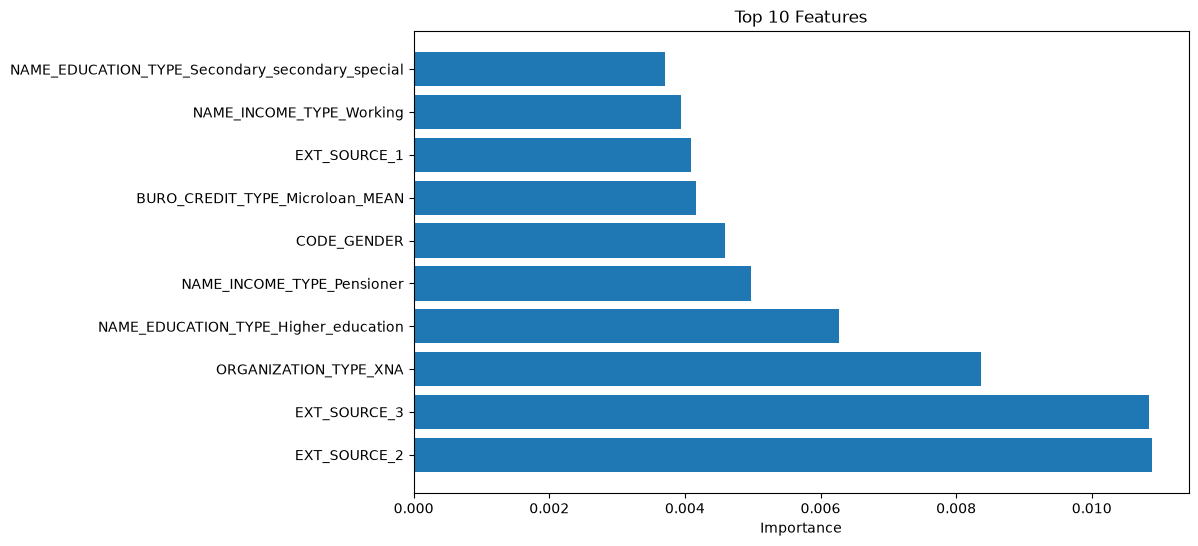

In [7]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Charger le modèle
model = joblib.load("app/model/model.pkl")

# Extraire l'importance (si disponible)
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    features = model.feature_names_in_
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Afficher les 10 features les plus importantes
    print(feature_importance.head(10))

    # Visualiser
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'].head(10), feature_importance['Importance'].head(10))
    plt.xlabel('Importance')
    plt.title('Top 10 Features')
    plt.show()
else:
    print("Le modèle ne fournit pas d'importance des features.")
